In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [2]:
import sys
print(sys.executable)

c:\Users\pc\Desktop\grad project\.venv\Scripts\python.exe


In [3]:
import re
import torch
from datasets import load_dataset
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown
from PIL import Image
import jiwer

c:\Users\pc\Desktop\grad project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model_id = "datalab-to/chandra-ocr-2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="cuda:0",
)
model.eval()
model.processor = AutoProcessor.from_pretrained(model_id)
model.processor.tokenizer.padding_side = "left"

W0710 17:17:09.501000 5324 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
c:\Users\pc\Desktop\grad project\.venv\Lib\site-packages\transformers\modeling_utils.py:5107: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  _ = torch.empty(int(byte_count // 2), dtype=torch.float16, device=device, requires_grad=False)
Loading weights:   0%|          | 2/724 [00:02<12:52,  1.07s/it]c:\Users\pc\Desktop\grad project\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release al

In [5]:
# Load the Arabic OCR test dataset
dataset = load_dataset("Omar-youssef/arabic-ocr-dataset", split="train")
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 30
})

In [6]:
def html_to_text(html: str) -> str:
    """Strip HTML tags from the dataset's ground-truth text and collapse whitespace."""
    text = re.sub(r"<[^>]+>", " ", html)
    text = re.sub(r"\s+", " ", text).strip()
    return text


predictions = []
references = []

for i, sample in enumerate(dataset):
    image = sample["image"].convert("RGB")
    reference_text = html_to_text(sample["text"])

    batch = [
        BatchInputItem(
            image=image,
            prompt_type="ocr_layout"   # preserves layout; good general default for Arabic docs
        )
    ]

    result = generate_hf(batch, model)[0]
    predicted_text = parse_markdown(result.raw)

    predictions.append(predicted_text)
    references.append(reference_text)

    print(f"Processed sample {i + 1}/{len(dataset)}")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
c:\Users\pc\Desktop\grad project\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Processed sample 1/30


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Processed sample 2/30


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


...

Processed sample 27/30


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Processed sample 28/30


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Processed sample 29/30
Processed sample 30/30


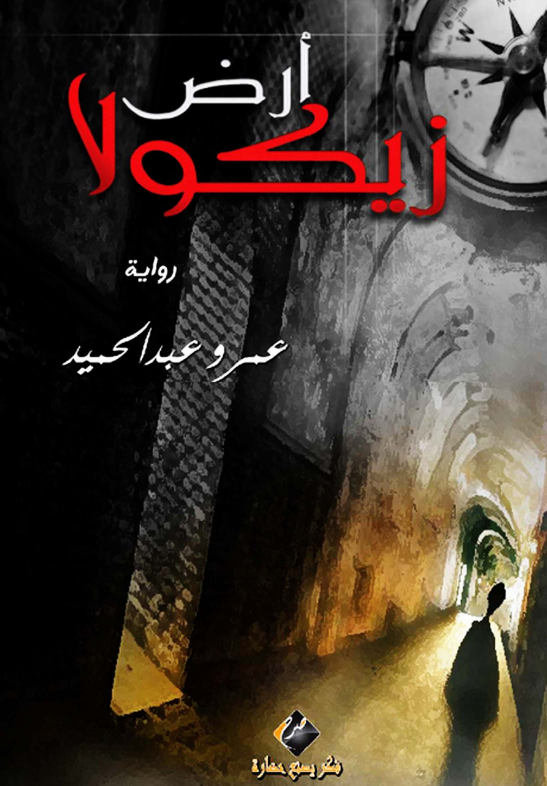

# أرض زيكولا

رواية

عمر و عبد الحفيد

![Publisher logo](8dd52c00931dbcdacd2cb42c766dca97_4_img.webp)A small diamond-shaped logo with a stylized graphic inside, likely representing the publisher.

نشرية معارة


In [7]:
from IPython.display import display

# Show the input image and the extracted (predicted) text for a single sample
sample_idx = 0

display(dataset[sample_idx]["image"])
print(predictions[sample_idx])

In [8]:
# Compute Word Error Rate (WER) and Character Error Rate (CER)
wer = jiwer.wer(references, predictions)
cer = jiwer.cer(references, predictions)

print(f"WER: {wer:.4f}")
print(f"CER: {cer:.4f}")

WER: 0.3031
CER: 0.1674


In [ ]:
import time
import os

from dotenv import load_dotenv
from google import genai

load_dotenv(override=True)

# Prioritized list of environment variable names for Gemini keys.
KEY_ENV_NAMES = ["GEMINI_API_KEY1", "GEMINI_API_KEY2", "GEMINI_API_KEY3"]
API_KEYS = [os.getenv(n) for n in KEY_ENV_NAMES if os.getenv(n)]
if not API_KEYS:
    raise RuntimeError(
        "No Gemini API keys found. Set one of: " + ", ".join(KEY_ENV_NAMES)
    )

GEMINI_MODEL = "gemini-2.5-flash"
GEMINI_OCR_PROMPT = (
    "Extract all text from this image via OCR.\n"
    "Preserve line breaks and punctuation exactly.\n"
    "Do NOT correct spelling mistakes.\n"
    "Do NOT translate the text.\n"
    "Output ONLY the extracted text, nothing else."
)


def _gemini_text(response) -> str:
    if response is None:
        return ""
    return (response.text or "").strip()


def _generate_with_key_rotation(prompt, image, max_key_attempts=1, backoff=1.0):
    """Try each API key in order. On 429 (rate-limit), rotate to the next key.

    Returns the SDK response or None if all keys are exhausted.
    """
    num_keys = len(API_KEYS)
    # Start with the first key in the list (GEMINI_API_KEY1 if present)
    for key_index in range(num_keys):
        key = API_KEYS[key_index]
        client = genai.Client(api_key=key)
        attempts = 0
        while attempts <= max_key_attempts:
            try:
                return client.models.generate_content(
                    model=GEMINI_MODEL, contents=[prompt, image]
                )
            except Exception as e:
                # Heuristically detect 429 / Too Many Requests.
                err_text = str(e)
                status_code = None
                if hasattr(e, "status_code"):
                    status_code = getattr(e, "status_code")
                if status_code == 429 or "429" in err_text or "Too Many Requests" in err_text:
                    print(
                        f"Key {key_index + 1} ({KEY_ENV_NAMES[key_index]}) rate-limited (429). Rotating to next key."
                    )
                    # break inner loop to move to next key
                    break
                # For other errors, re-raise so user can see them
                raise
            finally:
                attempts += 1
                time.sleep(backoff)
    # All keys exhausted or no successful response
    print("All Gemini API keys exhausted or rate-limited; returning empty response.")
    return None


gemini_predictions = []

for i, sample in enumerate(dataset):
    image = sample["image"].convert("RGB")

    response = _generate_with_key_rotation(GEMINI_OCR_PROMPT, image)
    gemini_text = _gemini_text(response)
    if not gemini_text:
        print(f"WARNING: Gemini returned no text for sample {i + 1}/{len(dataset)}.")
    gemini_predictions.append(gemini_text)

    print(f"Processed sample {i + 1}/{len(dataset)}")
    time.sleep(1)  # stay under per-minute rate limits


Processed sample 1/30
Processed sample 2/30
Processed sample 3/30
Processed sample 4/30
Processed sample 5/30
Processed sample 6/30


ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 23.289554461s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.5-flash'

In [ ]:
# Compute Word Error Rate (WER) and Character Error Rate (CER) for Gemini 2.5 Flash
gemini_wer = jiwer.wer(references, gemini_predictions)
gemini_cer = jiwer.cer(references, gemini_predictions)

print(f"Gemini 2.5 Flash WER: {gemini_wer:.4f}")
print(f"Gemini 2.5 Flash CER: {gemini_cer:.4f}")